In [205]:
from sklearn import tree
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import log_loss
from sklearn.calibration import CalibratedClassifierCV
# from sklearn.decomposition import PCA

In [3]:
submission_data = pd.read_csv('/Users/user/untitled folder/HITs/2nd Grade/ML Advanced/Drafts/Module1_test1/data/sample_submission.csv')
test_data = pd.read_csv('/Users/user/untitled folder/HITs/2nd Grade/ML Advanced/Drafts/Module1_test1/data/test.csv')
train_data = pd.read_csv('/Users/user/untitled folder/HITs/2nd Grade/ML Advanced/Drafts/Module1_test1/data/train.csv')

In [4]:
submission_data.head()

,id,Status_C,Status_CL,Status_D
0,15000,0.628084,0.034788,0.337128
1,15001,0.628084,0.034788,0.337128
2,15002,0.628084,0.034788,0.337128
3,15003,0.628084,0.034788,0.337128
4,15004,0.628084,0.034788,0.337128


In [5]:
test_data.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage
0,15000,1329.0,NaN,13149.0,F,NaN,NaN,NaN,N,0.9,NaN,4.04,NaN,NaN,NaN,NaN,190.0,11.1,2.0
1,15001,1235.0,Placebo,15601.0,F,N,N,N,N,0.5,408.0,3.91,67.0,1636.0,71.00,137.0,311.0,10.6,3.0
2,15002,2635.0,NaN,16802.0,F,NaN,NaN,NaN,N,2.3,NaN,3.42,NaN,NaN,NaN,NaN,171.0,9.9,4.0
3,15003,786.0,Placebo,16839.0,F,N,Y,Y,N,6.7,374.0,3.74,105.0,1911.0,128.65,135.0,354.0,11.9,4.0
4,15004,1097.0,NaN,24472.0,F,NaN,NaN,NaN,N,0.6,NaN,3.15,NaN,NaN,NaN,NaN,471.0,10.8,2.0


In [6]:
train_data.head()

,id,N_Days,Drug,Age,Sex,Ascites,Hepatomegaly,Spiders,Edema,Bilirubin,Cholesterol,Albumin,Copper,Alk_Phos,SGOT,Tryglicerides,Platelets,Prothrombin,Stage,Status
0,0,3445.0,D-penicillamine,15105.0,F,N,Y,Y,N,0.8,253.0,3.03,52.0,1032.0,70.00,62.0,334.0,11.5,4.0,D
1,1,2103.0,Placebo,22336.0,F,N,Y,N,N,0.6,NaN,3.01,58.0,678.0,71.30,NaN,344.0,11.6,4.0,C
2,2,939.0,Placebo,12369.0,F,N,N,N,N,0.4,NaN,3.75,13.0,1995.0,128.65,NaN,233.0,10.1,3.0,C
3,3,935.0,NaN,25202.0,F,NaN,NaN,NaN,N,4.2,NaN,3.12,NaN,NaN,NaN,NaN,273.0,10.2,1.0,C
4,4,4795.0,NaN,19358.0,F,NaN,NaN,NaN,N,4.5,NaN,3.40,NaN,NaN,NaN,NaN,114.0,13.6,4.0,D


In [7]:
train_data.isnull().sum()

id                  0
N_Days              0
Drug             6590
Age                 0
Sex                 0
Ascites          6581
Hepatomegaly     6591
Spiders          6591
Edema               0
Bilirubin           0
Cholesterol      8473
Albumin             0
Copper           6700
Alk_Phos         6596
SGOT             6598
Tryglicerides    8522
Platelets         557
Prothrombin        16
Stage               0
Status              0
dtype: int64

In [8]:
train_data_1 = train_data

In [9]:
X = train_data_1.drop(['Cholesterol', 'Tryglicerides', 'Status'], axis=1)
y = train_data_1.Status

In [10]:
X.head()
y.head()

0    D
1    C
2    C
3    C
4    D
Name: Status, dtype: object

In [11]:
clf = tree.DecisionTreeClassifier(criterion='entropy')

In [12]:
X = pd.get_dummies(X)

In [13]:
pd.set_option('display.max_columns', None)
X.head()

,id,N_Days,Age,Bilirubin,Albumin,Copper,Alk_Phos,SGOT,Platelets,Prothrombin,Stage,Drug_D-penicillamine,Drug_Placebo,Sex_F,Sex_M,Sex_M.0,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_M,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y
0,0,3445.0,15105.0,0.8,3.03,52.0,1032.0,70.00,334.0,11.5,4.0,True,False,True,False,False,True,False,False,True,False,False,True,True,False,False
1,1,2103.0,22336.0,0.6,3.01,58.0,678.0,71.30,344.0,11.6,4.0,False,True,True,False,False,True,False,False,True,False,True,False,True,False,False
2,2,939.0,12369.0,0.4,3.75,13.0,1995.0,128.65,233.0,10.1,3.0,False,True,True,False,False,True,False,True,False,False,True,False,True,False,False
3,3,935.0,25202.0,4.2,3.12,NaN,NaN,NaN,273.0,10.2,1.0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
4,4,4795.0,19358.0,4.5,3.40,NaN,NaN,NaN,114.0,13.6,4.0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False


In [14]:
X.isnull().sum()

id                         0
N_Days                     0
Age                        0
Bilirubin                  0
Albumin                    0
Copper                  6700
Alk_Phos                6596
SGOT                    6598
Platelets                557
Prothrombin               16
Stage                      0
Drug_D-penicillamine       0
Drug_Placebo               0
Sex_F                      0
Sex_M                      0
Sex_M.0                    0
Ascites_N                  0
Ascites_Y                  0
Hepatomegaly_N             0
Hepatomegaly_Y             0
Spiders_M                  0
Spiders_N                  0
Spiders_Y                  0
Edema_N                    0
Edema_S                    0
Edema_Y                    0
dtype: int64

In [15]:
imputer = SimpleImputer(strategy='median', add_indicator=True)
features_to_impute = ['Copper', 'Alk_Phos', 'SGOT', 'Platelets', 'Prothrombin']
imputed_data = imputer.fit_transform(X[features_to_impute])

In [16]:
indicator_names = [f"{col}_is_nan" for col in features_to_impute]
new_cols = features_to_impute + indicator_names

df_imputed = pd.DataFrame(imputed_data, columns=new_cols)

# Добавляем обратно колонки, которые не требовали импутации
X_final = pd.concat([df_imputed, X.drop(columns=features_to_impute)], axis=1)

In [17]:
X_final.head()

,Copper,Alk_Phos,SGOT,Platelets,Prothrombin,Copper_is_nan,Alk_Phos_is_nan,SGOT_is_nan,Platelets_is_nan,Prothrombin_is_nan,id,N_Days,Age,Bilirubin,Albumin,Stage,Drug_D-penicillamine,Drug_Placebo,Sex_F,Sex_M,Sex_M.0,Ascites_N,Ascites_Y,Hepatomegaly_N,Hepatomegaly_Y,Spiders_M,Spiders_N,Spiders_Y,Edema_N,Edema_S,Edema_Y
0,52.0,1032.0,70.00,334.0,11.5,0.0,0.0,0.0,0.0,0.0,0,3445.0,15105.0,0.8,3.03,4.0,True,False,True,False,False,True,False,False,True,False,False,True,True,False,False
1,58.0,678.0,71.30,344.0,11.6,0.0,0.0,0.0,0.0,0.0,1,2103.0,22336.0,0.6,3.01,4.0,False,True,True,False,False,True,False,False,True,False,True,False,True,False,False
2,13.0,1995.0,128.65,233.0,10.1,0.0,0.0,0.0,0.0,0.0,2,939.0,12369.0,0.4,3.75,3.0,False,True,True,False,False,True,False,True,False,False,True,False,True,False,False
3,52.0,1072.0,97.65,273.0,10.2,1.0,1.0,1.0,0.0,0.0,3,935.0,25202.0,4.2,3.12,1.0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False
4,52.0,1072.0,97.65,114.0,13.6,1.0,1.0,1.0,0.0,0.0,4,4795.0,19358.0,4.5,3.40,4.0,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False


In [18]:
clf.fit(X_final, y)

DecisionTreeClassifier(criterion='entropy')

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.33, random_state=42)

In [25]:
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [21]:
clf.score(X_test, y_test)

0.7701010101010101

In [32]:
clf = tree.DecisionTreeClassifier()

In [27]:
# clf.score(X_train, y_train)

0.8372139303482588

In [31]:
# cross_val_score(clf, X_train, y_train, cv=5).mean()

0.8245771144278606

In [35]:
parameters = {'criterion': ['gini', 'entropy'], 'max_depth': range(1,35), 'max_leaf_nodes': range(1, 7)}
grid_search_cv_clf = GridSearchCV(clf, parameters, cv=5)
grid_search_cv_clf.fit(X_train, y_train)


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
340 fits failed out of a total of 2040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
340 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File 

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 35),
                         'max_leaf_nodes': range(1, 7)})

In [36]:
grid_search_cv_clf.best_params_

{'criterion': 'entropy', 'max_depth': 3, 'max_leaf_nodes': 6}

In [39]:
best_clf = grid_search_cv_clf.best_estimator_

In [67]:
y_pred = best_clf.predict(X_test)
scores_list = [best_clf.score(X_test, y_test), precision_score(y_test, y_pred, average='macro'), recall_score(y_test, y_pred, average='macro')]

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [68]:
scores_list

[0.816969696969697, 0.53117874591136, 0.5242727371789156]

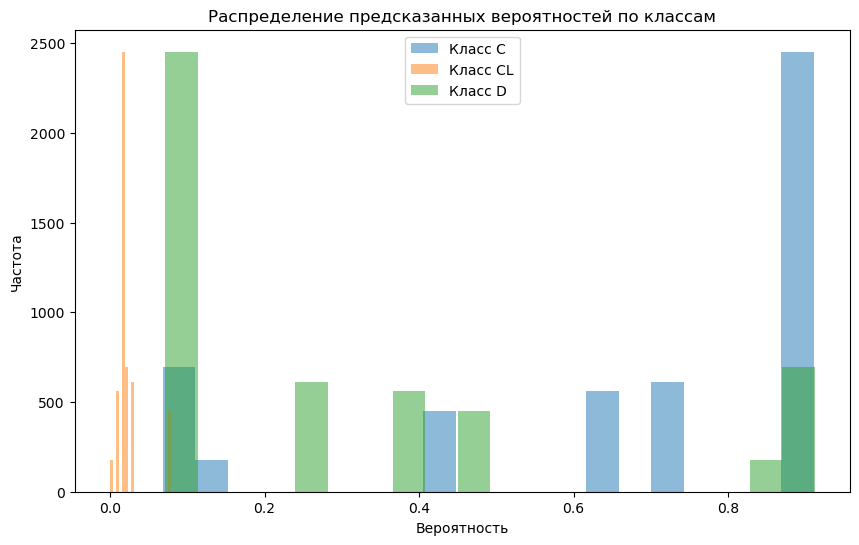

In [75]:
# pd.Series(y_predicted_prob[:, 1]).hist()
plt.figure(figsize=(10, 6))
classes = best_clf.classes_

for i in range(3):
    plt.hist(y_predicted_prob[:, i], bins=20, alpha=0.5, label=f'Класс {classes[i]}')

plt.title('Распределение предсказанных вероятностей по классам')
plt.xlabel('Вероятность')
plt.ylabel('Частота')
plt.legend() # Добавляет легенду, чтобы различить цвета
plt.show()

In [73]:
print(best_clf.classes_)

['C' 'CL' 'D']


In [77]:
f1 = f1_score(y_test, y_pred, average='macro')

In [78]:
f1

0.5260507674263617

In [ ]:
best_clf.

In [84]:
# best_clf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X.columns, 
    'Importance': best_clf.feature_importances_
})

# Сортируем по убыванию
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                 Feature  Importance
13             Bilirubin    0.578049
4            Prothrombin    0.311057
11                N_Days    0.055573
15                 Stage    0.055321
23        Hepatomegaly_N    0.000000
19                 Sex_M    0.000000
20               Sex_M.0    0.000000
21             Ascites_N    0.000000
22             Ascites_Y    0.000000
24        Hepatomegaly_Y    0.000000
17          Drug_Placebo    0.000000
25             Spiders_M    0.000000
26             Spiders_N    0.000000
27             Spiders_Y    0.000000
28               Edema_N    0.000000
29               Edema_S    0.000000
18                 Sex_F    0.000000
0                 Copper    0.000000
16  Drug_D-penicillamine    0.000000
1               Alk_Phos    0.000000
14               Albumin    0.000000
12                   Age    0.000000
10                    id    0.000000
9     Prothrombin_is_nan    0.000000
8       Platelets_is_nan    0.000000
7            SGOT_is_nan    0.000000
6

In [100]:
X_fixed = X_final[['Bilirubin', 'Prothrombin', 'N_Days', 'Stage']]

In [101]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_fixed, y, test_size=0.33, random_state=42)
best_clf.fit(X_train2, y_train2)
# X_fixed

DecisionTreeClassifier(criterion='entropy', max_depth=3, max_leaf_nodes=6)

In [102]:
f1 = f1_score(y_test, y_pred, average='macro')

In [103]:
f1

0.5260507674263617

In [108]:
X = train_data.drop('Status', axis=1)
X = pd.get_dummies(X)

imputer = SimpleImputer(strategy='median', add_indicator=True)
features_to_impute = ['Copper', 'Alk_Phos', 'SGOT', 'Platelets', 'Prothrombin']
imputed_data = imputer.fit_transform(X[features_to_impute])

indicator_names = [f"{col}_is_nan" for col in features_to_impute]
new_cols = features_to_impute + indicator_names

df_imputed = pd.DataFrame(imputed_data, columns=new_cols)

# Добавляем обратно колонки, которые не требовали импутации
X_final = pd.concat([df_imputed, X.drop(columns=features_to_impute)], axis=1)

In [121]:
X_train_origin, X_test_origin, y_train_origin, y_test_origin = train_test_split(X_final, y, test_size=0.33, random_state=42)
clf = tree.DecisionTreeClassifier()

parameters = {'criterion': ['gini', 'entropy'], 'max_depth': range(1,35), 'max_leaf_nodes': range(1, 7)}
grid_search_cv_clf = GridSearchCV(clf, parameters, cv=5)
grid_search_cv_clf.fit(X_train_origin, y_train_origin)


/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
340 fits failed out of a total of 2040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
340 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File 

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 35),
                         'max_leaf_nodes': range(1, 7)})

In [122]:
grid_search_cv_clf.best_params_

{'criterion': 'entropy', 'max_depth': 3, 'max_leaf_nodes': 6}

In [124]:
best_clf = grid_search_cv_clf.best_estimator_
y_pred = best_clf.predict(X_test_origin)
f1 = f1_score(y_test_origin, y_pred, average='macro')

f1

0.5260507674263617

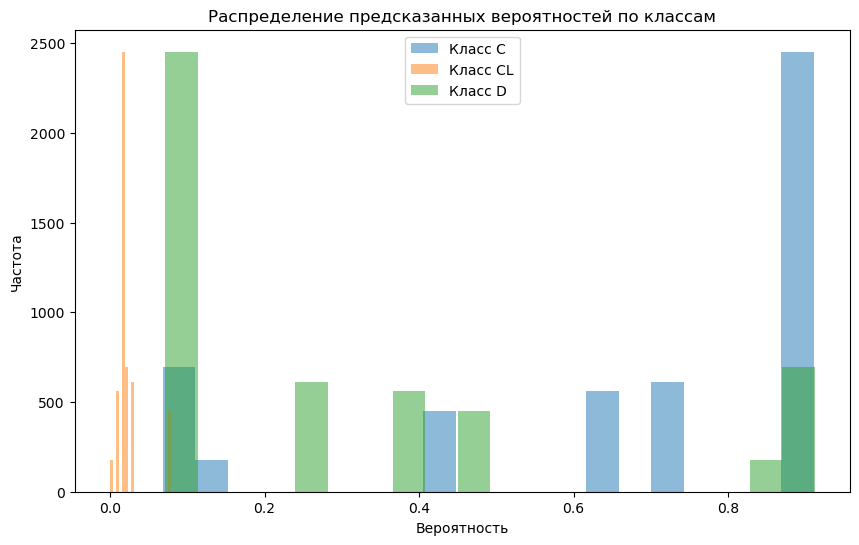

In [126]:
y_predicted_prob = best_clf.predict_proba(X_test_origin)
# pd.Series(y_predicted_prob[:, 1]).hist()
plt.figure(figsize=(10, 6))
classes = best_clf.classes_

for i in range(3):
    plt.hist(y_predicted_prob[:, i], bins=20, alpha=0.5, label=f'Класс {classes[i]}')

plt.title('Распределение предсказанных вероятностей по классам')
plt.xlabel('Вероятность')
plt.ylabel('Частота')
plt.legend() # Добавляет легенду, чтобы различить цвета
plt.show()

In [127]:
# best_clf.feature_importances_
feature_importance = pd.DataFrame({
    'Feature': X_final.columns, 
    'Importance': best_clf.feature_importances_
})

# Сортируем по убыванию
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

print(feature_importance)

                 Feature  Importance
13             Bilirubin    0.578049
4            Prothrombin    0.311057
11                N_Days    0.055573
17                 Stage    0.055321
24             Ascites_Y    0.000000
20                 Sex_F    0.000000
21                 Sex_M    0.000000
22               Sex_M.0    0.000000
23             Ascites_N    0.000000
0                 Copper    0.000000
19          Drug_Placebo    0.000000
26        Hepatomegaly_Y    0.000000
27             Spiders_M    0.000000
28             Spiders_N    0.000000
29             Spiders_Y    0.000000
30               Edema_N    0.000000
31               Edema_S    0.000000
25        Hepatomegaly_N    0.000000
16         Tryglicerides    0.000000
18  Drug_D-penicillamine    0.000000
1               Alk_Phos    0.000000
15               Albumin    0.000000
14           Cholesterol    0.000000
12                   Age    0.000000
10                    id    0.000000
9     Prothrombin_is_nan    0.000000
8

In [129]:
y_predicted_prob = best_clf.predict_proba(X_test_origin)
y_pred = np.where(y_predicted_prob[:, 1] > 0.8, 1, 0)

In [134]:
list(best_clf.predict(X_test_origin)).count(1)

0

In [138]:
X_fixed = X_final[['Bilirubin', 'Prothrombin', 'N_Days', 'Stage']]
X_train, X_test, y_train, y_test = train_test_split(X_fixed, y, test_size=0.33, random_state=42)

In [143]:
clf = tree.DecisionTreeClassifier()
params = {'criterion': ['gini', 'entropy'], 'max_depth': range(1,35), 'max_leaf_nodes': range(1, 7)}
grid_search_cv_clf = GridSearchCV(clf, params, cv=5)
grid_search_cv_clf.fit(X_train, y_train)

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
340 fits failed out of a total of 2040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
340 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1466, in wrapper
    estimator._validate_params()
  File "/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 666, in _validate_params
    validate_parameter_constraints(
  File 

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(1, 35),
                         'max_leaf_nodes': range(1, 7)})

In [144]:
grid_search_cv_clf.best_params_

{'criterion': 'entropy', 'max_depth': 3, 'max_leaf_nodes': 6}

In [145]:
best_clf = grid_search_cv_clf.best_estimator_

In [178]:
y_predicted_prob = best_clf.predict_proba(X_test)
y_pred = np.where(y_predicted_prob[:, 2] > 0.9, 1, 0)

In [169]:
best_clf.score(X_test, y_test)

0.816969696969697

In [170]:
best_clf.score(X_fixed, y)

0.8158

In [154]:
best_clf.predict(X_test)

array(['D', 'C', 'C', ..., 'D', 'D', 'D'], dtype=object)

In [155]:
y_predicted_prob

array([[0.06819813, 0.0201005 , 0.91170136],
       [0.91105388, 0.01723455, 0.07171157],
       [0.91105388, 0.01723455, 0.07171157],
       ...,
       [0.4308779 , 0.07870838, 0.49041372],
       [0.4308779 , 0.07870838, 0.49041372],
       [0.06819813, 0.0201005 , 0.91170136]])

In [168]:
list(y_pred).count(1)

696

In [162]:
best_clf.classes_

array(['C', 'CL', 'D'], dtype=object)

In [176]:
y_pred = best_clf.predict(X_test)
scores_list = [best_clf.score(X_test, y_test), precision_score(y_test, y_pred, average='macro'), recall_score(y_test, y_pred, average='macro')]

/opt/homebrew/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [177]:
scores_list

[0.816969696969697, 0.53117874591136, 0.5242727371789156]

In [183]:
y_pred = best_clf.predict(X_fixed)

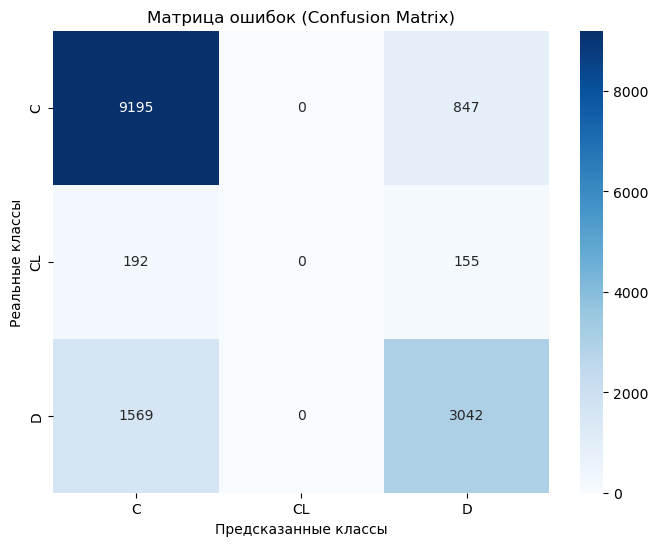

In [185]:
cm = confusion_matrix(y, y_pred)

# 3. Визуализируем через Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_clf.classes_, 
            yticklabels=best_clf.classes_)

plt.title('Матрица ошибок (Confusion Matrix)')
plt.ylabel('Реальные классы')
plt.xlabel('Предсказанные классы')
plt.show()

In [186]:
rf_clf = RandomForestClassifier()

In [188]:
parameters = {'n_estimators':[10, 20, 30], 
              'max_depth': range(3, 21, 2), 
              'min_samples_split': range(100, 401, 50),
              'min_samples_leaf': range(10, 51, 10)
             }

In [190]:
grid_search_cv_rf_clf = GridSearchCV(rf_clf, parameters, cv=5)

In [191]:
grid_search_cv_rf_clf.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': range(3, 21, 2),
                         'min_samples_leaf': range(10, 51, 10),
                         'min_samples_split': range(100, 401, 50),
                         'n_estimators': [10, 20, 30]})

In [193]:
best_rf_clf = grid_search_cv_rf_clf.best_estimator_

In [192]:
grid_search_cv_rf_clf.best_params_

{'max_depth': 7,
 'min_samples_leaf': 40,
 'min_samples_split': 200,
 'n_estimators': 20}

In [194]:
best_rf_clf.score(X_test, y_test)

0.8414141414141414

In [204]:
y_pred_proba = best_rf_clf.predict_proba(X[['Bilirubin', 'Prothrombin', 'N_Days', 'Stage']])
log_loss(y, y_pred_proba)

0.4280381422242412

In [199]:
best_rf_clf.feature_importances_

array([0.38227983, 0.3269027 , 0.23601316, 0.05480431])

In [202]:
cross_val_score(best_rf_clf, X_train, y_train, cv=5).mean()

0.835820895522388

In [210]:
calibrated_rf = CalibratedClassifierCV(best_rf_clf, cv='prefit', method='sigmoid')
calibrated_rf.fit(X_train, y_train)

# Проверяем новый log_loss
new_probs = calibrated_rf.predict_proba(X[['Bilirubin', 'Prothrombin', 'N_Days', 'Stage']])

In [211]:
log_loss(y, new_probs)

0.4318447303579204

In [212]:
y_pred_proba

array([[0.52057662, 0.00532238, 0.474101  ],
       [0.5769991 , 0.0054315 , 0.4175694 ],
       [0.94315376, 0.01673491, 0.04011133],
       ...,
       [0.49642025, 0.03989828, 0.46368147],
       [0.95744946, 0.01011041, 0.03244013],
       [0.87703259, 0.01118936, 0.11177805]])